<a href="https://colab.research.google.com/github/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri/blob/main/notebooks/01_real_fastmri_zero_filled_reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!git clone https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri.git

Cloning into 'reliability-aware-ssdu-mri'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 97 (delta 43), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 47.81 KiB | 1.91 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [12]:
%cd reliability-aware-ssdu-mri

/content/reliability-aware-ssdu-mri/reliability-aware-ssdu-mri/reliability-aware-ssdu-mri


In [13]:
!ls

configs  docs	      LICENSE	 README.md  src
data	 experiments  notebooks  results    tests


**Connect Python to your src/ code**

In [14]:
import sys
sys.path.append("src")

from transforms import ifft2c
from reconstruction import zero_filled_reconstruction, normalize_to_unit_range

print("Project code imported successfully.")

Project code imported successfully.


**Locate the saved fastMRI .h5 file in Drive**

In [15]:
!find /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted -name "*.h5" | head

/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_209_6001154.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_207_2070082.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_201_2010421.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT1POST_202_6000343.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_209_2090032.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT1_202_2020391.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_207_2070312.h5
/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT1POST_202_6000291.h5
/content/drive/MyDri

**Load one real .h5 file cleanly**

In [16]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

file_path = "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5"

with h5py.File(file_path, "r") as hf:
    print("Keys:", list(hf.keys()))
    print("Attributes:")
    for key, value in hf.attrs.items():
        print(key, ":", value)

    kspace = hf["kspace"][:]
    mask = hf["mask"][:]

print("K-space shape:", kspace.shape)
print("Mask shape:", mask.shape)
print("K-space dtype:", kspace.dtype)
print("Mask dtype:", mask.dtype)

Keys: ['ismrmrd_header', 'kspace', 'mask']
Attributes:
acceleration : 4
acquisition : AXT2
num_low_frequency : 32
patient_id : 2ec2dfc85e9ee10c4875af47b361957495df908a87d476f0603426ca93a5f2bc
K-space shape: (16, 16, 768, 396)
Mask shape: (396,)
K-space dtype: complex64
Mask dtype: float32


In [17]:
# Select central slice
slice_index = kspace.shape[0] // 2
kspace_slice = kspace[slice_index]

print("Selected slice index:", slice_index)
print("Selected k-space slice shape:", kspace_slice.shape)

# Zero-filled RSS reconstruction
zf_image = zero_filled_reconstruction(kspace_slice, mask=None, coil_axis=0)
zf_norm = normalize_to_unit_range(zf_image)

print("Reconstructed image shape:", zf_image.shape)
print("Min:", zf_image.min())
print("Max:", zf_image.max())

Selected slice index: 8
Selected k-space slice shape: (16, 768, 396)
Reconstructed image shape: (768, 396)
Min: 1.866878e-06
Max: 0.00045775695


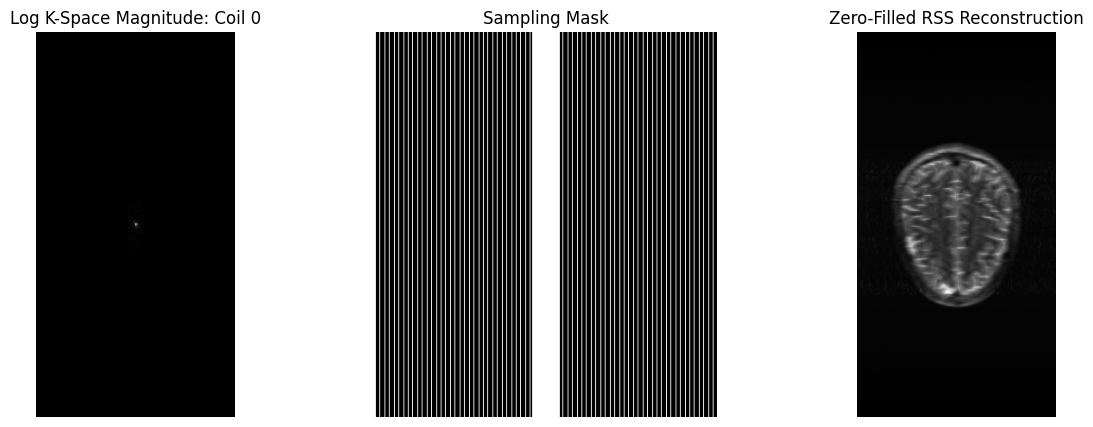

In [19]:
# Visualize
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(np.log1p(np.abs(kspace_slice[0])), cmap="gray")
plt.title("Log K-Space Magnitude: Coil 0")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask[None, :], cmap="gray", aspect="auto")
plt.title("Sampling Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(zf_norm, cmap="gray")
plt.title("Zero-Filled RSS Reconstruction")
plt.axis("off")

plt.show()

#**Test src/fastmri_data.py in Colab**

**Pull latest GitHub changes**

In [33]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 958 bytes | 958.00 KiB/s, done.
From https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri
   9561ec4..7707504  main       -> origin/main
Updating 9561ec4..7707504
Fast-forward
 src/{data.py => fastmri_data.py} | 0
 1 file changed, 0 insertions(+), 0 deletions(-)
 rename src/{data.py => fastmri_data.py} (100%)


In [34]:
!ls src












fastmri_data.py  masks.py    __pycache__  reconstruction.py
__init__.py	 metrics.py  README.md	  transforms.py


**Import the fastMRI data utilities**

In [35]:
import sys

# Add project source folder to Python path
sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

from fastmri_data import (
    load_fastmri_file,
    print_fastmri_summary,
    get_kspace_slice,
)

print("fastmri_data.py imported successfully.")

fastmri_data.py imported successfully.


**Load and inspect one fastMRI brain file**

In [36]:
file_path = "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5"

data = load_fastmri_file(file_path)

print_fastmri_summary(data)

File path: /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5
Keys: ['ismrmrd_header', 'kspace', 'mask']

Attributes:
acceleration: 4
acquisition: AXT2
num_low_frequency: 32
patient_id: 2ec2dfc85e9ee10c4875af47b361957495df908a87d476f0603426ca93a5f2bc

K-space shape: (16, 16, 768, 396)
K-space dtype: complex64
Mask shape: (396,)
Mask dtype: float32


**Extract the central k-space slice**

In [37]:
kspace_slice, slice_index = get_kspace_slice(data["kspace"])

print("Selected slice index:", slice_index)
print("Selected k-space slice shape:", kspace_slice.shape)

Selected slice index: 8
Selected k-space slice shape: (16, 768, 396)


**Reconstruct using the reusable loader**

Zero-filled image shape: (768, 396)
Min intensity: 1.866878e-06
Max intensity: 0.00045775695


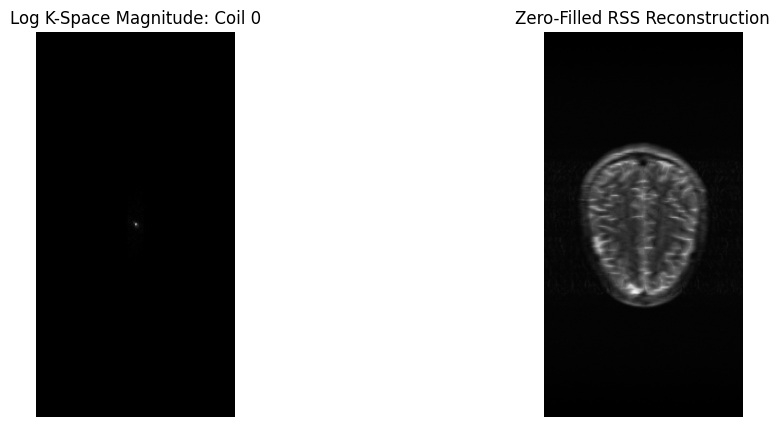

In [38]:
from reconstruction import zero_filled_reconstruction, normalize_to_unit_range
import matplotlib.pyplot as plt
import numpy as np

zf_image = zero_filled_reconstruction(kspace_slice, mask=None, coil_axis=0)
zf_norm = normalize_to_unit_range(zf_image)

print("Zero-filled image shape:", zf_image.shape)
print("Min intensity:", zf_image.min())
print("Max intensity:", zf_image.max())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.log1p(np.abs(kspace_slice[0])), cmap="gray")
plt.title("Log K-Space Magnitude: Coil 0")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(zf_norm, cmap="gray")
plt.title("Zero-Filled RSS Reconstruction")
plt.axis("off")

plt.show()

#**Pull visualization.py into Colab and test it**

In [39]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 7 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 60.68 KiB | 1.01 MiB/s, done.
From https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri
   7707504..9502863  main       -> origin/main
Updating 7707504..9502863
Fast-forward
 01_real_fastmri_zero_filled_reconstruction.ipynb | 289 ++++++++++++++++++++++-
 src/visualization.py                             | 102 ++++++++
 2 files changed, 388 insertions(+), 3 deletions(-)
 create mode 100644 src/visualization.py


In [40]:
#import the new visualization utilities:
import sys
sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

from visualization import show_kspace_and_reconstruction, show_full_and_crop

print("visualization.py imported successfully.")

visualization.py imported successfully.


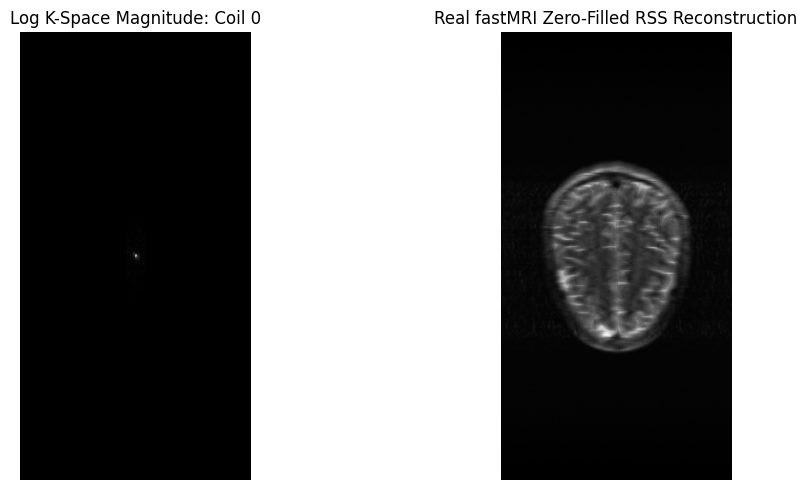

In [41]:
#test it using the reconstruction
show_kspace_and_reconstruction(
    kspace_slice=kspace_slice,
    reconstructed_image=zf_norm,
    title="Real fastMRI Zero-Filled RSS Reconstruction"
)

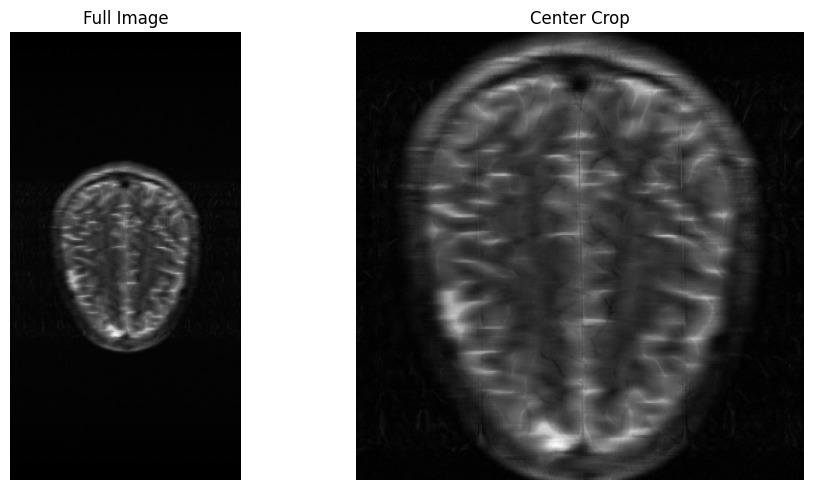

Cropped image shape: (320, 320)


In [42]:
#crop the image
zf_crop = show_full_and_crop(
    zf_norm,
    crop_size=(320, 320)
)

print("Cropped image shape:", zf_crop.shape)

#**Check reference-data availability**

In [43]:
import h5py
from pathlib import Path

data_dir = Path("/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test")

h5_files = sorted(list(data_dir.glob("*.h5")))

print("Number of .h5 files:", len(h5_files))
print("First file:", h5_files[0])

with h5py.File(h5_files[0], "r") as hf:
    print("Keys:", list(hf.keys()))
    print("Attributes:", dict(hf.attrs))

Number of .h5 files: 186
First file: /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXFLAIR_200_6002527.h5
Keys: ['ismrmrd_header', 'kspace', 'mask']
Attributes: {'acceleration': np.int64(4), 'acquisition': 'AXFLAIR', 'num_low_frequency': np.int64(26), 'patient_id': 'f426088638b86dc2507548fdb24e3df8e35591f412533d3a337b3790fa330d33'}


#**Test the fastMRI directory scanner in Colab**

In [44]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 20 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (20/20), 392.66 KiB | 1.77 MiB/s, done.
From https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri
   9502863..4cd17d3  main       -> origin/main
Updating 9502863..4cd17d3
Fast-forward
 01_real_fastmri_zero_filled_reconstruction.ipynb   | 151 +++-
 docs/data_status.md                                |  71 ++
 ...1_real_fastmri_zero_filled_reconstruction.ipynb | 799 +++++++++++++++++++++
 src/fastmri_data.py                                |  45 ++
 4 files changed, 1064 insertions(+), 2 deletions(-)
 create mode 100644 docs/data_status.md
 create mode 100644 notebooks/01_real_fastmri_zero_filled_reconstruction.ipynb


In [46]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


In [48]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import fastmri_data
importlib.reload(fastmri_data)

from fastmri_data import scan_fastmri_directory

print("Scanner imported successfully.")

Scanner imported successfully.


In [49]:
data_dir = "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test"

records = scan_fastmri_directory(data_dir)

print("Number of files scanned:", len(records))
records[0]

Number of files scanned: 186


{'file_path': '/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXFLAIR_200_6002527.h5',
 'filename': 'file_brain_AXFLAIR_200_6002527.h5',
 'keys': ['ismrmrd_header', 'kspace', 'mask'],
 'attrs': {'acceleration': np.int64(4),
  'acquisition': 'AXFLAIR',
  'num_low_frequency': np.int64(26),
  'patient_id': 'f426088638b86dc2507548fdb24e3df8e35591f412533d3a337b3790fa330d33'},
 'kspace_shape': (16, 16, 640, 320),
 'kspace_dtype': 'complex64',
 'mask_shape': (320,),
 'mask_dtype': 'float32',
 'has_reference': False}

**Convert scan records into a summary table**

In [50]:
import pandas as pd

summary_rows = []

for record in records:
    attrs = record["attrs"]

    summary_rows.append({
        "filename": record["filename"],
        "acquisition": attrs.get("acquisition", None),
        "acceleration": attrs.get("acceleration", None),
        "num_low_frequency": attrs.get("num_low_frequency", None),
        "kspace_shape": record["kspace_shape"],
        "mask_shape": record["mask_shape"],
        "has_reference": record["has_reference"],
    })

df = pd.DataFrame(summary_rows)

df.head()

,filename,acquisition,acceleration,num_low_frequency,kspace_shape,mask_shape,has_reference
0,file_brain_AXFLAIR_200_6002527.h5,AXFLAIR,4,26,"(16, 16, 640, 320)","(320,)",False
1,file_brain_AXFLAIR_200_6002621.h5,AXFLAIR,4,26,"(16, 16, 640, 320)","(320,)",False
2,file_brain_AXFLAIR_200_6002625.h5,AXFLAIR,4,26,"(16, 20, 640, 320)","(320,)",False
3,file_brain_AXFLAIR_200_6002635.h5,AXFLAIR,4,26,"(16, 16, 640, 320)","(320,)",False
4,file_brain_AXFLAIR_201_6002943.h5,AXFLAIR,4,26,"(16, 20, 640, 320)","(320,)",False


In [51]:
print("Number of files:", len(df))

print("\nAcquisition counts:")
print(df["acquisition"].value_counts())

print("\nAcceleration counts:")
print(df["acceleration"].value_counts())

print("\nReference availability:")
print(df["has_reference"].value_counts())

Number of files: 186

Acquisition counts:
acquisition
AXT2        106
AXT1POST     39
AXFLAIR      17
AXT1PRE      14
AXT1         10
Name: count, dtype: int64

Acceleration counts:
acceleration
4    98
8    88
Name: count, dtype: int64

Reference availability:
has_reference
False    186
Name: count, dtype: int64


In [52]:
summary_path = "results/fastmri_test_batch_0_summary.csv"

df.to_csv(summary_path, index=False)

print("Saved summary to:", summary_path)

Saved summary to: results/fastmri_test_batch_0_summary.csv


#**Test src/ssdu.py in Colab**

In [80]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


**Import the SSDU utilities:**

In [77]:
!ls src

fastmri_data.py  masks.py    README.md		ssdu.py        visualization.py
__init__.py	 metrics.py  reconstruction.py	transforms.py


In [78]:
import sys
sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

from ssdu import split_acquired_mask, check_disjoint_masks, mask_fraction

print("SSDU utilities imported successfully.")

SSDU utilities imported successfully.


In [79]:
theta_mask, lambda_mask = split_acquired_mask(
    mask=data["mask"],
    rho=0.4,
    seed=42
)

print("Original acquired mask fraction:", mask_fraction(data["mask"]))
print("Theta mask fraction:", mask_fraction(theta_mask))
print("Lambda mask fraction:", mask_fraction(lambda_mask))
print("Are Theta and Lambda disjoint?", check_disjoint_masks(theta_mask, lambda_mask))
print("Theta + Lambda equals acquired mask?", ((theta_mask + lambda_mask) == data["mask"]).all())

Original acquired mask fraction: 0.25
Theta mask fraction: 0.14898989898989898
Lambda mask fraction: 0.10101010101010101
Are Theta and Lambda disjoint? True
Theta + Lambda equals acquired mask? True


**Visualize the SSDU split**

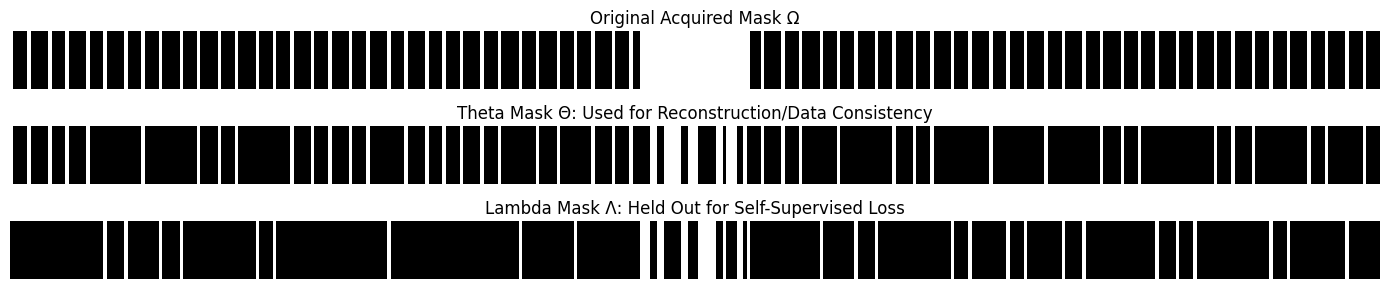

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 3))

plt.subplot(3, 1, 1)
plt.imshow(data["mask"][None, :], cmap="gray", aspect="auto")
plt.title("Original Acquired Mask Ω")
plt.axis("off")

plt.subplot(3, 1, 2)
plt.imshow(theta_mask[None, :], cmap="gray", aspect="auto")
plt.title("Theta Mask Θ: Used for Reconstruction/Data Consistency")
plt.axis("off")

plt.subplot(3, 1, 3)
plt.imshow(lambda_mask[None, :], cmap="gray", aspect="auto")
plt.title("Lambda Mask Λ: Held Out for Self-Supervised Loss")
plt.axis("off")

plt.tight_layout()
plt.show()

**Test reusable SSDU mask visualization in Colab**

In [87]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import visualization
importlib.reload(visualization)

from visualization import show_ssdu_masks

print("SSDU visualization imported successfully.")

SSDU visualization imported successfully.


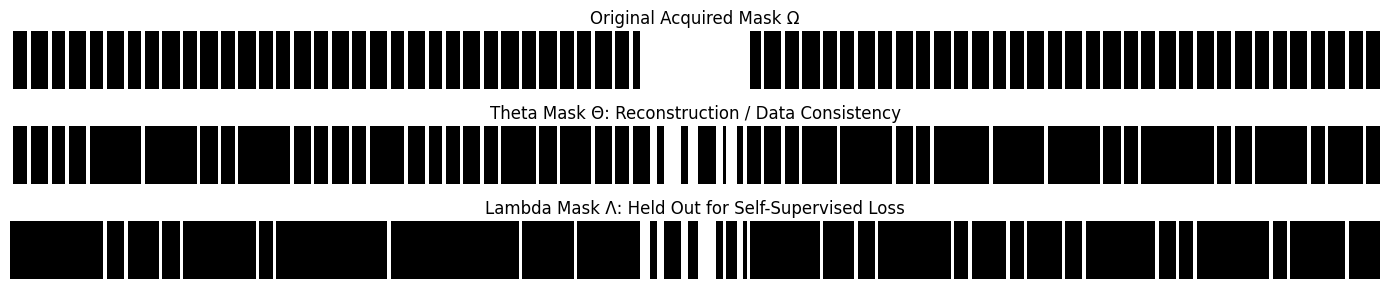

In [88]:
show_ssdu_masks(
    acquired_mask=data["mask"],
    theta_mask=theta_mask,
    lambda_mask=lambda_mask
)

#**Test src/losses.py in Colab**

In [89]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 12 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (12/12), 44.52 KiB | 221.00 KiB/s, done.
From https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri
   40dd9c3..52e3d14  main       -> origin/main
Updating 40dd9c3..52e3d14
Fast-forward
 experiments/experiment_003_ssdu_mask_split.md      |  93 ++++++++
 ...1_real_fastmri_zero_filled_reconstruction.ipynb | 253 ++++++++++++++++++++-
 src/losses.py                                      | 112 +++++++++
 3 files changed, 450 insertions(+), 8 deletions(-)
 create mode 100644 experiments/experiment_003_ssdu_mask_split.md
 create mode 100644 src/losses.py


In [92]:
import sys
sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

from losses import expand_mask, heldout_kspace_residual, ssdu_l2_loss

print("SSDU loss utilities imported successfully.")

from transforms import ifft2c

# Reconstruct coil images from measured k-space slice
coil_images = ifft2c(kspace_slice)

print("Coil images shape:", coil_images.shape)
print("Measured k-space shape:", kspace_slice.shape)
print("Lambda mask shape:", lambda_mask.shape)

SSDU loss utilities imported successfully.
Coil images shape: (16, 768, 396)
Measured k-space shape: (16, 768, 396)
Lambda mask shape: (396,)


In [93]:

residual = heldout_kspace_residual(
    reconstructed_coil_images=coil_images,
    measured_kspace=kspace_slice,
    lambda_mask=lambda_mask,
)

loss = ssdu_l2_loss(
    reconstructed_coil_images=coil_images,
    measured_kspace=kspace_slice,
    lambda_mask=lambda_mask,
)

print("Held-out residual shape:", residual.shape)
print("SSDU L2 loss:", loss)

Held-out residual shape: (16, 768, 396)
SSDU L2 loss: 2.4267389e-14


**nonzero held-out residual**

In [94]:
from losses import heldout_kspace_residual, ssdu_l2_loss, expand_mask
from transforms import ifft2c
import numpy as np

# Expand Theta mask to match multicoil k-space shape
theta_expanded = expand_mask(theta_mask, kspace_slice.shape)

# Use only Theta k-space for reconstruction
kspace_theta = theta_expanded * kspace_slice

# Reconstruct coil images from Theta only
coil_images_theta = ifft2c(kspace_theta)

# Evaluate against held-out Lambda measurements
residual_theta_lambda = heldout_kspace_residual(
    reconstructed_coil_images=coil_images_theta,
    measured_kspace=kspace_slice,
    lambda_mask=lambda_mask,
)

loss_theta_lambda = ssdu_l2_loss(
    reconstructed_coil_images=coil_images_theta,
    measured_kspace=kspace_slice,
    lambda_mask=lambda_mask,
)

print("Theta-only k-space shape:", kspace_theta.shape)
print("Theta-only coil images shape:", coil_images_theta.shape)
print("Held-out residual shape:", residual_theta_lambda.shape)
print("Theta-to-Lambda SSDU loss:", loss_theta_lambda)

Theta-only k-space shape: (16, 768, 396)
Theta-only coil images shape: (16, 768, 396)
Held-out residual shape: (16, 768, 396)
Theta-to-Lambda SSDU loss: 1.0


**Visualize the held-out residual energy**

Residual energy shape: (16, 768, 396)
Coil-summed residual energy shape: (768, 396)


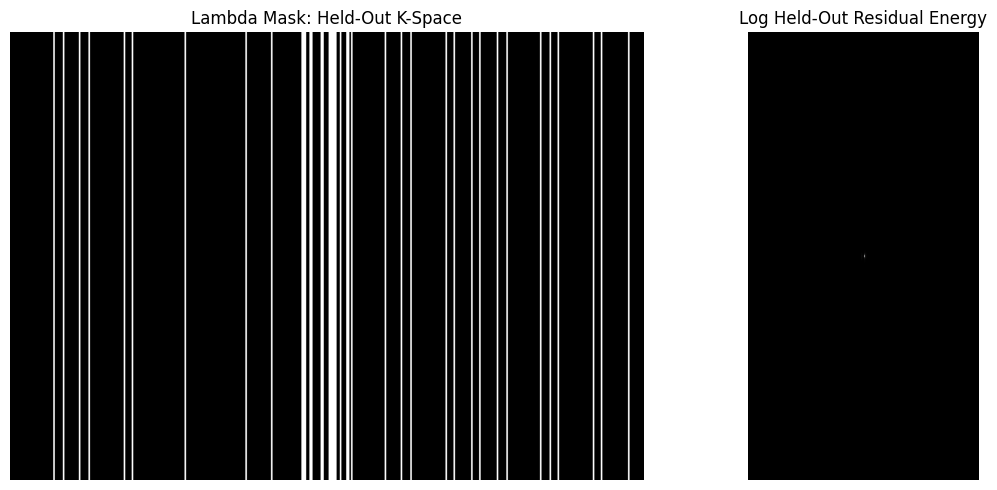

In [95]:
# Compute residual energy in k-space
residual_energy = np.abs(residual_theta_lambda) ** 2

# Sum across coils for visualization
residual_energy_coil_sum = residual_energy.sum(axis=0)

print("Residual energy shape:", residual_energy.shape)
print("Coil-summed residual energy shape:", residual_energy_coil_sum.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(lambda_mask[None, :], cmap="gray", aspect="auto")
plt.title("Lambda Mask: Held-Out K-Space")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.log1p(residual_energy_coil_sum), cmap="gray")
plt.title("Log Held-Out Residual Energy")
plt.axis("off")

plt.tight_layout()
plt.show()

#**Backproject held-out residual into image domain**

Residual image coils shape: (16, 768, 396)
Residual image energy shape: (768, 396)


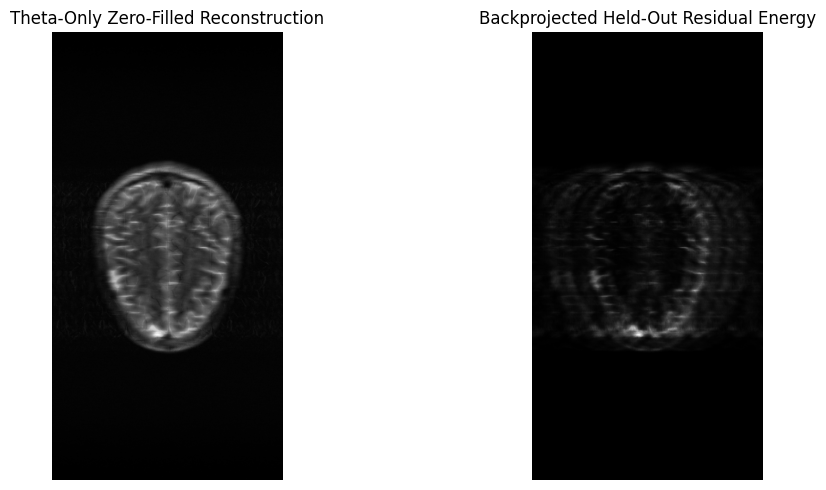

In [96]:
from transforms import ifft2c
from reconstruction import normalize_to_unit_range
import numpy as np
import matplotlib.pyplot as plt

# Backproject held-out residual into image domain
residual_image_coils = ifft2c(residual_theta_lambda)

# Convert multicoil residual image to residual energy map
residual_image_energy = np.sum(np.abs(residual_image_coils) ** 2, axis=0)

# Normalize for visualization
residual_image_energy_norm = normalize_to_unit_range(residual_image_energy)

print("Residual image coils shape:", residual_image_coils.shape)
print("Residual image energy shape:", residual_image_energy.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(zf_norm, cmap="gray")
plt.title("Theta-Only Zero-Filled Reconstruction")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(residual_image_energy_norm, cmap="gray")
plt.title("Backprojected Held-Out Residual Energy")
plt.axis("off")

plt.tight_layout()
plt.show()

#**Test the reusable residual backprojection functions in Colab**

In [4]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


In [8]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import losses
importlib.reload(losses)

from losses import (
    backproject_kspace_residual,
    residual_energy_map,
    heldout_residual_energy_map,
)

print("Residual backprojection utilities imported successfully.")

Residual backprojection utilities imported successfully.


In [9]:
# Method 1: step-by-step
residual_image_coils = backproject_kspace_residual(residual_theta_lambda)
energy_map_1 = residual_energy_map(residual_image_coils, coil_axis=0)

# Method 2: combined utility
energy_map_2 = heldout_residual_energy_map(
    reconstructed_coil_images=coil_images_theta,
    measured_kspace=kspace_slice,
    lambda_mask=lambda_mask,
)

print("Residual image coils shape:", residual_image_coils.shape)
print("Energy map 1 shape:", energy_map_1.shape)
print("Energy map 2 shape:", energy_map_2.shape)

difference = np.max(np.abs(energy_map_1 - energy_map_2))
print("Max difference between methods:", difference)

Residual image coils shape: (16, 768, 396)
Energy map 1 shape: (768, 396)
Energy map 2 shape: (768, 396)
Max difference between methods: 0.0


#**Test src/uncertainty.py in Colab**

In [10]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 8 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 2.87 KiB | 84.00 KiB/s, done.
From https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri
   491b5e2..854bf59  main       -> origin/main
Updating 491b5e2..854bf59
Fast-forward
 ...1_real_fastmri_zero_filled_reconstruction.ipynb | 124 ++++++++++++++++++++-
 src/uncertainty.py                                 | 115 +++++++++++++++++++
 2 files changed, 238 insertions(+), 1 deletion(-)
 create mode 100644 src/uncertainty.py


In [11]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import uncertainty
importlib.reload(uncertainty)

from uncertainty import (
    mean_reconstruction,
    voxelwise_variance,
    normalize_map,
    uncertainty_residual_alignment,
)

print("Uncertainty utilities imported successfully.")

Uncertainty utilities imported successfully.


**temporary stochastic reconstruction test using noisy versions of the zero-filled image**

In [13]:
from reconstruction import zero_filled_reconstruction, normalize_to_unit_range

# Recreate zero-filled RSS reconstruction from the current kspace_slice
zf_image = zero_filled_reconstruction(
    kspace=kspace_slice,
    mask=None,
    coil_axis=0
)

zf_norm = normalize_to_unit_range(zf_image)

print("zf_image shape:", zf_image.shape)
print("zf_norm shape:", zf_norm.shape)

zf_image shape: (768, 396)
zf_norm shape: (768, 396)


In [14]:
# Create synthetic stochastic reconstructions from the current zero-filled image
# This is only a code test, not the final uncertainty method.

T = 8
rng = np.random.default_rng(42)

stochastic_recons = []

for _ in range(T):
    noise = rng.normal(loc=0.0, scale=0.02, size=zf_norm.shape)
    stochastic_recons.append(zf_norm + noise)

stochastic_recons = np.stack(stochastic_recons, axis=0)

mean_img = mean_reconstruction(stochastic_recons)
uncertainty_map = voxelwise_variance(stochastic_recons)
uncertainty_norm = normalize_map(uncertainty_map)

print("Stochastic reconstructions shape:", stochastic_recons.shape)
print("Mean image shape:", mean_img.shape)
print("Uncertainty map shape:", uncertainty_map.shape)

Stochastic reconstructions shape: (8, 768, 396)
Mean image shape: (768, 396)
Uncertainty map shape: (768, 396)


In [15]:
alignment = uncertainty_residual_alignment(
    uncertainty_map=uncertainty_map,
    residual_energy_map=energy_map_2,
)

print("Uncertainty-residual alignment:", alignment)

Uncertainty-residual alignment: -0.001631915508393084


**Visualize the artificial uncertainty test**

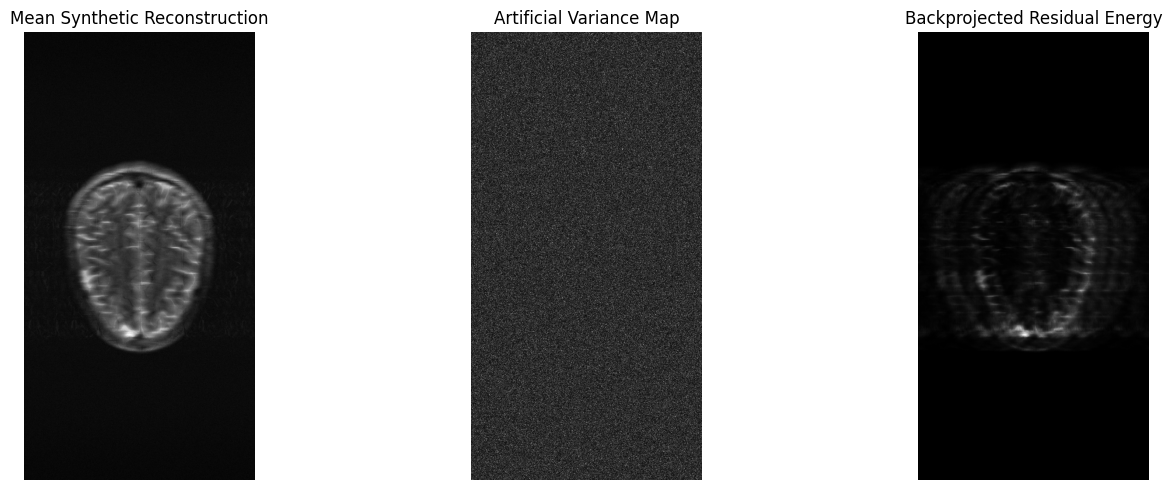

Uncertainty-residual alignment: -0.001631915508393084


In [16]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mean_img, cmap="gray")
plt.title("Mean Synthetic Reconstruction")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(uncertainty_norm, cmap="gray")
plt.title("Artificial Variance Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(normalize_map(energy_map_2), cmap="gray")
plt.title("Backprojected Residual Energy")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Uncertainty-residual alignment:", alignment)

#**Test SimpleCNNReconstructor**

In [17]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 35 (delta 19), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (35/35), 328.81 KiB | 2.57 MiB/s, done.
From https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri
   854bf59..db7167f  main       -> origin/main
Updating 854bf59..db7167f
Fast-forward
 docs/method_development_status.md                  | 169 +++++++++++++
 .../experiment_007_artificial_uncertainty_test.md  | 100 ++++++++
 .../experiment_008_uncertainty_utility_test.md     | 102 ++++++++
 ...1_real_fastmri_zero_filled_reconstruction.ipynb | 269 ++++++++++++++++++++-
 notebooks/02_ssdu_reconstruction_baseline_plan.md  | 143 +++++++++++
 src/models/README.md                               |  49 ++++
 src/models/__init__.py                             |   5 +
 src/models/simple_cnn.py                           |  55 

In [18]:
import sys
sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

from models import SimpleCNNReconstructor

import torch

print("SimpleCNNReconstructor imported successfully.")

SimpleCNNReconstructor imported successfully.


In [19]:
model = SimpleCNNReconstructor(
    in_channels=1,
    out_channels=1,
    features=32
)

# Dummy image batch: batch x channels x height x width
x = torch.randn(1, 1, 320, 320)

with torch.no_grad():
    y = model(x)

print("Input shape:", x.shape)
print("Output shape:", y.shape)

Input shape: torch.Size([1, 1, 320, 320])
Output shape: torch.Size([1, 1, 320, 320])


**Run real-data forward pass**

In [20]:
from reconstruction import zero_filled_reconstruction, normalize_to_unit_range
from visualization import center_crop
from models import SimpleCNNReconstructor

import torch
import numpy as np

# Reconstruct Theta-only zero-filled image
zf_theta = zero_filled_reconstruction(
    kspace=kspace_theta,
    mask=None,
    coil_axis=0
)

# Normalize
zf_theta_norm = normalize_to_unit_range(zf_theta)

# Center crop to manageable size
zf_theta_crop = center_crop(zf_theta_norm, crop_size=(320, 320))

# Convert to PyTorch tensor: batch x channel x height x width
input_tensor = torch.from_numpy(zf_theta_crop).float()
input_tensor = input_tensor.unsqueeze(0).unsqueeze(0)

print("Input tensor shape:", input_tensor.shape)

# Create model
model = SimpleCNNReconstructor(
    in_channels=1,
    out_channels=1,
    features=32
)

# Forward pass
model.eval()
with torch.no_grad():
    output_tensor = model(input_tensor)

print("Output tensor shape:", output_tensor.shape)

Input tensor shape: torch.Size([1, 1, 320, 320])
Output tensor shape: torch.Size([1, 1, 320, 320])


**connect the CNN output to the SSDU loss**

In [21]:
import torch
import numpy as np

from transforms import fft2c
from losses import expand_mask

# Convert CNN output back to NumPy image
output_image = output_tensor.detach().cpu().numpy()[0, 0]

print("CNN output image shape:", output_image.shape)

# For now, this is a single-channel image-domain output.
# To compare with multicoil k-space, we use a simplified temporary approach:
# replicate the output across coils to match kspace dimensions.

num_coils = kspace_slice.shape[0]

output_coil_images = np.repeat(
    output_image[None, :, :],
    repeats=num_coils,
    axis=0
)

print("Output coil images shape:", output_coil_images.shape)
print("Measured k-space slice shape:", kspace_slice.shape)

CNN output image shape: (320, 320)
Output coil images shape: (16, 320, 320)
Measured k-space slice shape: (16, 768, 396)


**CNN on the full-size image**

In [22]:
from reconstruction import zero_filled_reconstruction, normalize_to_unit_range
from models import SimpleCNNReconstructor

import torch
import numpy as np

# Reconstruct Theta-only zero-filled image at full spatial size
zf_theta_full = zero_filled_reconstruction(
    kspace=kspace_theta,
    mask=None,
    coil_axis=0
)

# Normalize full image
zf_theta_full_norm = normalize_to_unit_range(zf_theta_full)

print("Full Theta-only image shape:", zf_theta_full_norm.shape)

# Convert full image to PyTorch tensor: batch x channel x height x width
input_full_tensor = torch.from_numpy(zf_theta_full_norm).float()
input_full_tensor = input_full_tensor.unsqueeze(0).unsqueeze(0)

print("Full input tensor shape:", input_full_tensor.shape)

# Create model
model_full = SimpleCNNReconstructor(
    in_channels=1,
    out_channels=1,
    features=16
)

# Forward pass
model_full.eval()
with torch.no_grad():
    output_full_tensor = model_full(input_full_tensor)

print("Full output tensor shape:", output_full_tensor.shape)

Full Theta-only image shape: (768, 396)
Full input tensor shape: torch.Size([1, 1, 768, 396])
Full output tensor shape: torch.Size([1, 1, 768, 396])


**Connect full-size CNN output toward SSDU loss**

In [26]:
from transforms import fft2c
from losses import ssdu_l2_loss
import numpy as np

# Convert full CNN output to NumPy image
output_full_image = output_full_tensor.detach().cpu().numpy()[0, 0]

print("CNN full output image shape:", output_full_image.shape)

# Temporary simplified multicoil expansion
# This is only a pipeline test, not the final physical model.
num_coils = kspace_slice.shape[0]

output_full_coil_images = np.repeat(
    output_full_image[None, :, :],
    repeats=num_coils,
    axis=0
)

print("Temporary output coil images shape:", output_full_coil_images.shape)
print("Measured k-space slice shape:", kspace_slice.shape)

# Compute SSDU loss on Lambda
cnn_ssdu_loss = ssdu_l2_loss(
    reconstructed_coil_images=output_full_coil_images,
    measured_kspace=kspace_slice,
    lambda_mask=lambda_mask,
)

print("Temporary CNN-to-Lambda SSDU loss:", cnn_ssdu_loss)

CNN full output image shape: (768, 396)
Temporary output coil images shape: (16, 768, 396)
Measured k-space slice shape: (16, 768, 396)
Temporary CNN-to-Lambda SSDU loss: 38491630.0
